## ARTI308 - Machine Learning  
## Lab 4: Data Quality Assessment & Preprocessing  

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

from google.colab import files
uploaded = files.upload()

df = pd.read_csv("StudentsPerformance.csv")
df.head()

Saving StudentsPerformance.csv to StudentsPerformance.csv


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


 ## 1. Data Quality Assessment  
### 1.1 Check Data Types

In [4]:
df.dtypes

,0
gender,object
race/ethnicity,object
parental level of education,object
lunch,object
test preparation course,object
math score,int64
reading score,int64
writing score,int64


### 1.2 Check Missing Values


In [5]:
df.isna().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


## 2. Handling Missing Values  
### 2.1 Introduce Artificial Missing Values

In [6]:
df_missing = df.copy()
df_missing.loc[0:5, 'math score'] = np.nan
df_missing.isna().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,6
reading score,0
writing score,0


### Strategy 1: Remove Records

In [7]:
df_removed = df_missing.dropna()

print("Original shape:", df_missing.shape)
print("After removing missing rows:", df_removed.shape)

df_removed.isna().sum()

Original shape: (1000, 8)
After removing missing rows: (994, 8)


,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


### Strategy 2: Mean Imputation

In [12]:
df_imputed_mean = df_missing.copy()

df_imputed_mean['math score'].fillna(
    df_imputed_mean['math score'].mean(),
    inplace=True
)

df_imputed_mean.isna().sum()

/tmp/ipython-input-405/2773826461.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_imputed_mean['math score'].fillna(


,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


### Strategy 3: Median Imputation (Preferred)

The median is more robust to outliers and is suitable for score data.

In [13]:
df_imputed_median = df_missing.copy()

df_imputed_median['math score'].fillna(
    df_imputed_median['math score'].median(),
    inplace=True
)

df_imputed_median.isna().sum()

/tmp/ipython-input-405/1287629644.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_imputed_median['math score'].fillna(


,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


## 3. Handling Outliers  
### Detect Outliers using IQR


Boxplot

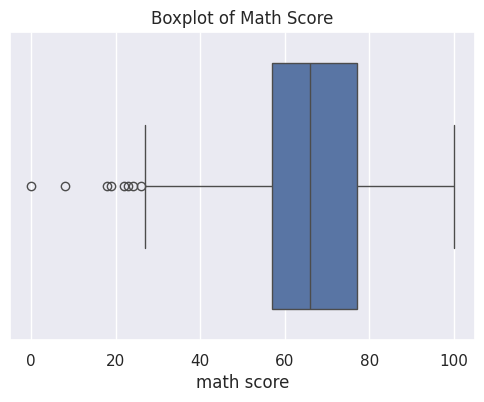

In [14]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['math score'])
plt.title("Boxplot of Math Score")
plt.show()


Detect using IQR

In [15]:
Q1 = df['math score'].quantile(0.25)
Q3 = df['math score'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['math score'] < lower) | (df['math score'] > upper)]

outliers.head()


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
17,female,group B,some high school,free/reduced,none,18,32,28
59,female,group C,some high school,free/reduced,none,0,17,10
145,female,group C,some college,free/reduced,none,22,39,33
338,female,group B,some high school,free/reduced,none,24,38,27
466,female,group D,associate's degree,free/reduced,none,26,31,38


Remove Outliers

In [16]:
df_no_outliers = df[(df['math score'] >= lower) & (df['math score'] <= upper)]
df_no_outliers.shape

(992, 8)

Capping Outliers

In [17]:
lower_cap = df['math score'].quantile(0.05)
upper_cap = df['math score'].quantile(0.95)

df_capped = df.copy()
df_capped['math score'] = df_capped['math score'].clip(lower_cap, upper_cap)

df_capped.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72.0,72,74
1,female,group C,some college,standard,completed,69.0,90,88
2,female,group B,master's degree,standard,none,90.0,95,93
3,male,group A,associate's degree,free/reduced,none,47.0,57,44
4,male,group C,some college,standard,none,76.0,78,75


## 4. Data Transformation - Normalization

 Min-Max Normalization

In [18]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_scaled = df[['math score', 'reading score', 'writing score']].copy()
df_scaled[['math score', 'reading score', 'writing score']] = scaler.fit_transform(df_scaled)

df_scaled.head()

,math score,reading score,writing score
0,0.72,0.662651,0.711111
1,0.69,0.879518,0.866667
2,0.90,0.939759,0.922222
3,0.47,0.481928,0.377778
4,0.76,0.734940,0.722222


 Z-Score Standardization

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_standardized = df[['math score', 'reading score', 'writing score']].copy()
df_standardized[['math score', 'reading score', 'writing score']] = scaler.fit_transform(df_standardized)

df_standardized.head()

,math score,reading score,writing score
0,0.390024,0.193999,0.391492
1,0.192076,1.427476,1.313269
2,1.577711,1.770109,1.642475
3,-1.259543,-0.833899,-1.583744
4,0.653954,0.605158,0.457333


## 5. Check Correlation Before Applying PCA

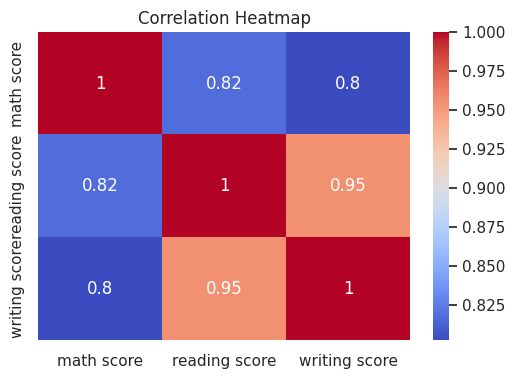

In [20]:
plt.figure(figsize=(6,4))
sns.heatmap(
    df_standardized[['math score', 'reading score', 'writing score']].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

## 6. Principal Component Analysis (PCA)

In [21]:
from sklearn.decomposition import PCA

X = df_standardized[['math score', 'reading score', 'writing score']]

pca = PCA(n_components=3)
principal_components = pca.fit_transform(X)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.90614325 0.07886171 0.01499504]


PCA Scatter Plot

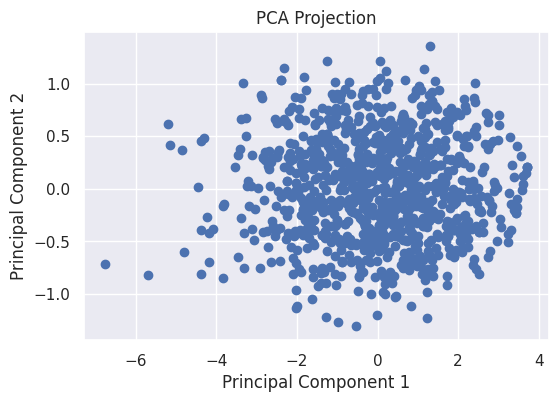

In [22]:
plt.figure(figsize=(6,4))
plt.scatter(principal_components[:,0], principal_components[:,1])
plt.title("PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()